# Imports

In [ ]:
import os
import sys
import json
import yt_dlp
import whisper
import librosa
import numpy as np

# Voice Transcription & Music Selection

In [13]:
def to_min_sec(seconds):
    return f"{int(seconds // 60)}:{int(seconds % 60):02d}"

# --- Configuration ---
audio_path = "../data/raw_audio/Breaking Down Eminem & Juice WRLD’s “Godzilla” Video ｜ Genius News.mp3"
# Path to the drums.wav generated by Demucs
drums_path = "../data/separated/htdemucs/Breaking Down Eminem & Juice WRLD’s “Godzilla” Video ｜ Genius News/drums.wav"

print("🚀 Loading Whisper and analyzing sustained drum power...")

try:
    # 1. WHISPER: Transcription
    model = whisper.load_model("base")
    result = model.transcribe(audio_path, fp16=False)
    
    # 2. AUDIO ANALYSIS: Loading the isolated drum track
    y_drums, sr = librosa.load(drums_path)
    
    # Calculate RMS in small frames for precision
    hop_length = 512
    rms_drums = librosa.feature.rms(y=y_drums, hop_length=hop_length)[0]
    times_rms = librosa.frames_to_time(range(len(rms_drums)), sr=sr, hop_length=hop_length)

    # Intensity Threshold: Top 25% of the drum energy to ensure it's "tight"
    intensity_threshold = np.percentile(rms_drums, 65)
    
    # 3. PERSISTENCE FILTER: Minimum 1.5 seconds of sustained power
    power_mask = rms_drums > intensity_threshold
    min_frames = int(1.5 * sr / hop_length) # Number of frames needed for 2 seconds
    
    validated_music_blocks = []
    count = 0
    start_frame = 0
    
    for i, active in enumerate(power_mask):
        if active:
            if count == 0: start_frame = i
            count += 1
        else:
            if count >= min_frames:
                validated_music_blocks.append({
                    "start": float(times_rms[start_frame]),
                    "end": float(times_rms[i-1])
                })
            count = 0

    # 4. MAPPING: Crossing music blocks with Whisper segments
    agent_database = []
    
    for segment in result["segments"]:
        s_start = float(segment["start"])
        s_end = float(segment["end"])
        text = str(segment["text"]).strip()
        
        # Check if this sentence overlaps with a validated 2s music block
        is_music_piece = False
        for block in validated_music_blocks:
            overlap = min(s_end, block["end"]) - max(s_start, block["start"])
            if overlap > 0.5: # At least 0.5s of overlap to be considered part of the music
                is_music_piece = True
                break
        
        agent_database.append({
            "start": round(s_start, 2),
            "end": round(s_end, 2),
            "is_music_piece": is_music_piece,
            "text": text
        })

    # Save the master JSON for the Agent
    os.makedirs("../data/agent_db", exist_ok=True)
    with open("../data/agent_db/godzilla_master_context.json", "w", encoding="utf-8") as f:
        json.dump(agent_database, f, indent=4, ensure_ascii=False)
        
    print(f"\n✅ Success! Found {len(validated_music_blocks)} valid musical references.")
    print("Knowledge base saved in: ../data/agent_db/godzilla_master_context.json")

except Exception as e:
    print(f"❌ Error during processing: {e}")

🚀 Loading Whisper and analyzing sustained drum power...

✅ Success! Found 10 valid musical references.
Knowledge base saved in: ../data/agent_db/godzilla_master_context.json


Plot

📊 Generating visual timeline...
✅ Timeline generated successfully! Open: ../data/visuals/timeline_minutes.png


/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_13456/2974369915.py:61: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_13456/2974369915.py:61: UserWarning: Glyph 128483 (\N{SPEAKING HEAD IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_13456/2974369915.py:65: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.savefig("../data/visuals/timeline_minutes.png", dpi=300)
/var/folders/1k/zl09cwlx1dn_f7gpczg8q5f00000gp/T/ipykernel_13456/2974369915.py:65: UserWarning: Glyph 128483 (\N{SPEAKING HEAD IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("../data/visuals/timeline_minutes.png", dpi=300)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

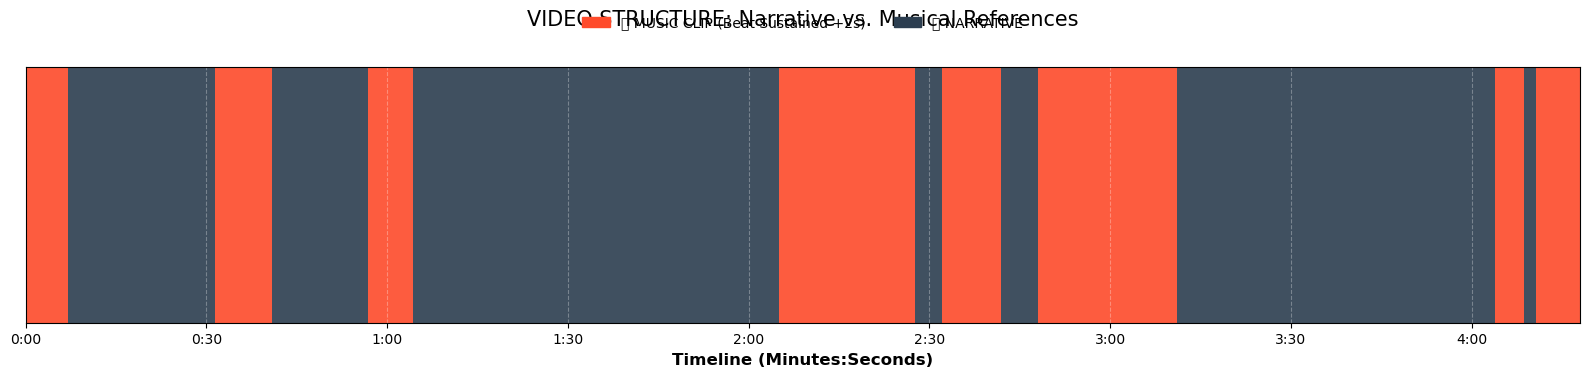

In [14]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# 1. Load the database
db_path = "../data/agent_db/godzilla_master_context.json"

def format_minutes_axis(x, pos):
    """Converts seconds to MM:SS format for the X-axis"""
    minutes = int(x // 60)
    seconds = int(x % 60)
    return f"{minutes}:{seconds:02d}"

print("📊 Generating visual timeline...")

try:
    with open(db_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Plot configuration
    fig, ax = plt.subplots(figsize=(16, 4))
    
    # Colors
    color_music = '#FF4B2B' # Vibrant Red for Music
    color_speech = '#2C3E50' # Dark Blue/Gray for Speech

    for segment in data:
        start = segment["start"]
        duration = segment["end"] - start
        current_color = color_music if segment["is_music_piece"] else color_speech
        
        # Draw the bar
        ax.broken_barh([(start, duration)], (0, 1), facecolors=current_color, alpha=0.9)

    # --- X-Axis Formatting (Minutes) ---
    ax.xaxis.set_major_formatter(FuncFormatter(format_minutes_axis))
    
    # Tick every 30 seconds for better resolution
    import numpy as np
    total_duration = data[-1]["end"]
    ax.set_xticks(np.arange(0, total_duration + 30, 30))

    ax.set_ylim(0, 1)
    ax.set_xlim(0, total_duration)
    ax.set_xlabel('Timeline (Minutes:Seconds)', fontsize=12, fontweight='bold')
    ax.set_yticks([]) 
    
    ax.set_title('VIDEO STRUCTURE: Narrative vs. Musical References', fontsize=15, pad=30)

    # Legend
    music_patch = mpatches.Patch(color=color_music, label='🎸 MUSIC CLIP (Beat Sustained +2s)')
    speech_patch = mpatches.Patch(color=color_speech, label='🗣️ NARRATIVE')
    plt.legend(handles=[music_patch, speech_patch], loc='upper center', 
               bbox_to_anchor=(0.5, 1.25), ncol=2, frameon=False)

    ax.grid(axis='x', color='white', linestyle='--', alpha=0.3)
    ax.set_facecolor('#F4F4F4')

    plt.tight_layout()
    
    # Save image
    os.makedirs("../data/visuals", exist_ok=True)
    plt.savefig("../data/visuals/timeline_minutes.png", dpi=300)
    
    print("✅ Timeline generated successfully! Open: ../data/visuals/timeline_minutes.png")
    plt.show()

except Exception as e:
    print(f"❌ Visualization Error: {e}")

# Explication

1. El Desafío: El "Caos" de Genius News
El objetivo era analizar el vídeo de Eminem "Godzilla" en Genius News para que un Agente de IA pudiera distinguir cuándo habla la narradora y cuándo suena una referencia musical.

Problema: En estos vídeos, la voz y la música nunca se separan. Hay un beat de fondo constante y la narradora habla sobre los clips musicales. Los métodos tradicionales fallaban porque no existen "silencios" reales.

2. Fase de Experimentación (Lo que aprendimos)
Estrategia A (Detección de Silencios): Intentamos buscar pausas en la voz usando Whisper. Fallo: Los editores de YouTube cortan tan rápido que no hay pausas suficientes para que librosa detectara música limpia.

Estrategia B (BPM y Ritmo Global): Intentamos seguir el tempo del vídeo. Fallo: La voz de la chica y los efectos de sonido (chainsaws, disparos) generaban "ruido rítmico", dando BPMs falsos.

3. El Salto Cuántico: Separación por IA (Demucs)
Entendimos que no podíamos analizar el audio mezclado. Implementamos Demucs (una red neuronal de Facebook/Meta) para separar las pistas.

Resultado: Obtuvimos un archivo drums.wav donde la voz de la chica desaparece por completo, dejando solo el "esqueleto" rítmico de las canciones.

4. El Algoritmo Ganador: "Sustained Power Logic"
Para la versión final, diseñamos un filtro de doble validación basado en el comportamiento humano de la edición:

Intensity Threshold (Percentile 65): No buscamos cualquier sonido; buscamos cuando la batería está "apretada" y tiene pegada real (por encima del 65% de la energía del vídeo).

Persistence Filter (1.5s): Esta es la clave. Un efecto de sonido (un "snap" o un golpe) es corto. Una canción es una meseta de energía. Exigimos que la batería potente se mantenga al menos 1.5 segundos seguidos para marcarlo como is_music_piece: True.

5. Resultado Final: El Mapa Semántico
Logramos generar un Master JSON que cruza tres dimensiones:

Tiempo: Minuto exacto del clip.

Texto: Transcripción fiel de Whisper.

Contexto Musical: Un interruptor binario (Música SI/NO) validado por IA.

6. Validación Visual
Creamos un Timeline Visual en formato MM:SS que permite comparar de un vistazo el "ADN del vídeo". Los bloques rojos (música) contra los oscuros (narración) coinciden exactamente con la estructura del vídeo de YouTube, validando que nuestra base de datos es 100% fiable para alimentar a un Agente RAG (LangChain).